# Model Testing Notebook

This notebook is extracted from the model-testing part of `scratch.ipynb`.

Key behavior:
- It automatically reads `tet_quality_mode` from the run's `train_config.json` based on the checkpoint path.
- If missing (older runs), it falls back to `"mean_ratio"`.
- The detected quality metric is printed and used consistently during evaluation.


In [1]:
import os
import re
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from tet_mat73_loader import TetMat73Dataset
from tet_mesh_topology_local import TetMeshTopology
from tet_env import softmin_score, worstk_mean_score

from model_face_edge_gpt import Mesh3DActorCritic
from initial_embedding import batch_from_obs, model_action_to_env_with_sizes


In [2]:
def round_id_from_ckpt(path: str) -> int:
    m = re.search(r"model_round(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


def resolve_quality_mode_from_ckpt(ckpt_path: str, default_mode: str = "mean_ratio") -> str:
    run_dir = os.path.dirname(os.path.abspath(ckpt_path))
    cfg_path = os.path.join(run_dir, "train_config.json")
    mode = default_mode

    if os.path.exists(cfg_path):
        try:
            with open(cfg_path, "r", encoding="utf-8") as f:
                cfg = json.load(f)
            mode = str(cfg.get("tet_quality_mode", default_mode))
            print(f"Loaded train config: {cfg_path}")
        except Exception as e:
            print(f"Warning: failed to read {cfg_path}: {e}")
            mode = default_mode
    else:
        print(f"No train_config.json found near checkpoint. Fallback to default: {default_mode}")

    if mode not in ("mean_ratio", "simpqual1", "simpqual2"):
        print(f"Unknown tet_quality_mode '{mode}', fallback to {default_mode}")
        mode = default_mode

    print(f"Using tet quality metric: {mode}")
    return mode


def obs_from_topo(
    topo: TetMeshTopology,
    *,
    step: int,
    no_improve: int,
    max_steps: int,
    patience_eval: int,
) -> dict:
    return dict(
        points=topo.points,
        tets=topo.tets,
        faces=topo.faces,
        face2tet=topo.face2tet,
        edges=topo.edges,
        candidate_mask=topo.candidate_mask(),
        tet_quality=topo.tet_quality,
        step_frac=float(step) / float(max(1, max_steps)),
        no_improve_frac=float(no_improve) / float(max(1, patience_eval)),
    )


def score_from_quality(q: np.ndarray, score_mode: str, softmin_tau: float, worstk_k: int) -> float:
    if score_mode == "softmin":
        return softmin_score(q, tau=softmin_tau)
    if score_mode == "worstk":
        return worstk_mean_score(q, k=worstk_k)
    raise ValueError(score_mode)


def build_model_from_ckpt(ckpt_path: str, device: torch.device, example_obs: dict):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model" in ckpt:
        state = ckpt["model"]
        cfg = ckpt.get("run_config", {})
    else:
        state = ckpt
        cfg = {}

    bg0 = batch_from_obs([example_obs], device=device)
    d_edge_in = bg0.edge_feat.shape[-1]
    d_face_in = bg0.face_feat.shape[-1]

    model = Mesh3DActorCritic(
        d_edge_in=d_edge_in,
        d_face_in=d_face_in,
        d_h=int(cfg.get("d_h", 128)),
        num_layers=int(cfg.get("num_layers", 4)),
        msg_hidden=int(cfg.get("msg_hidden", 128)),
        value_hidden=int(cfg.get("value_hidden", 128)),
        critic_extra_dim=int(cfg.get("critic_extra_dim", bg0.quality_feat.shape[-1])),
        use_coord_update=False,
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(device)

    model.load_state_dict(state, strict=True)
    model.eval()
    return model


In [3]:
@torch.inference_mode()
def run_agent_until_stall(
    P: np.ndarray,
    T_init: np.ndarray,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    tet_quality_mode="mean_ratio",
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    eps_improve=1e-6,
    patience_eval=80,
    max_steps=800,
    greedy=True,
    fallback_final_to_best=True,
):
    topo = TetMeshTopology(P, T_init.copy(), tet_quality_mode=tet_quality_mode)

    cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
    best = cur
    best_tets = topo.tets.copy()
    no_improve = 0
    steps = 0
    step_rewards = []

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(
            topo,
            step=steps,
            no_improve=no_improve,
            max_steps=max_steps,
            patience_eval=patience_eval,
        )
        bg = batch_from_obs([obs], device=device)

        policy_out, _, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            critic_global_feat=bg.quality_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]

        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)])

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            dist = torch.distributions.Categorical(logits=logits[valid_model_t])
            a_model = valid_model[int(dist.sample().item())]

        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        prev = cur
        ok = topo.apply_action(int(a_env))
        cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
        step_rewards.append(float(cur - prev))

        if ok and (cur - best) >= eps_improve:
            best = cur
            best_tets = topo.tets.copy()
            no_improve = 0
        else:
            no_improve += 1

        steps += 1
        if no_improve >= patience_eval:
            break

    if fallback_final_to_best:
        topo = TetMeshTopology(P, best_tets, tet_quality_mode=tet_quality_mode)
        final_score = best
    else:
        final_score = cur

    return topo, best, final_score, steps, step_rewards


def evaluate_checkpoint(
    ckpt_path: str,
    ds: TetMat73Dataset,
    test_ids: np.ndarray,
    T_good: np.ndarray,
    device: torch.device,
    *,
    tet_quality_mode="mean_ratio",
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    patience_eval=80,
    max_steps=800,
    greedy=True,
    fallback_final_to_best=True,
):
    i0 = int(test_ids[0])
    P0, Tbad0 = ds.get(i0)
    topo0 = TetMeshTopology(P0, Tbad0, tet_quality_mode=tet_quality_mode)
    model = build_model_from_ckpt(
        ckpt_path,
        device,
        obs_from_topo(topo0, step=0, no_improve=0, max_steps=max_steps, patience_eval=patience_eval),
    )

    rows = []
    step_reward_trajs = []
    for i in tqdm(test_ids, desc=f"Eval {os.path.basename(ckpt_path)}", leave=False):
        P, Tbad = ds.get(int(i))

        topo_bad = TetMeshTopology(P, Tbad, tet_quality_mode=tet_quality_mode)
        score_bad = score_from_quality(topo_bad.tet_quality, score_mode, softmin_tau, worstk_k)

        topo_good = TetMeshTopology(P, T_good, tet_quality_mode=tet_quality_mode)
        score_good = score_from_quality(topo_good.tet_quality, score_mode, softmin_tau, worstk_k)

        _, score_best, score_final, steps, step_rewards = run_agent_until_stall(
            P,
            Tbad,
            model,
            device,
            tet_quality_mode=tet_quality_mode,
            score_mode=score_mode,
            softmin_tau=softmin_tau,
            worstk_k=worstk_k,
            patience_eval=patience_eval,
            max_steps=max_steps,
            greedy=greedy,
            fallback_final_to_best=fallback_final_to_best,
        )

        rows.append((score_bad, score_final, score_best, score_good, steps))
        step_reward_trajs.append(step_rewards)

    arr = np.asarray(rows, dtype=np.float64)

    max_len = max((len(tr) for tr in step_reward_trajs), default=0)
    step_reward_mean = np.full(max_len, np.nan, dtype=np.float64)
    step_reward_count = np.zeros(max_len, dtype=np.int64)
    for t in range(max_len):
        vals = [tr[t] for tr in step_reward_trajs if t < len(tr)]
        if vals:
            step_reward_mean[t] = float(np.mean(vals))
            step_reward_count[t] = int(len(vals))

    return dict(
        ckpt=ckpt_path,
        round_id=round_id_from_ckpt(ckpt_path),
        n=len(rows),
        bad_mean=float(arr[:, 0].mean()),
        final_mean=float(arr[:, 1].mean()),
        best_mean=float(arr[:, 2].mean()),
        good_mean=float(arr[:, 3].mean()),
        improve_final=float((arr[:, 1] - arr[:, 0]).mean()),
        improve_best=float((arr[:, 2] - arr[:, 0]).mean()),
        gap_to_good=float((arr[:, 2] - arr[:, 3]).mean()),
        steps_mean=float(arr[:, 4].mean()),
        step_reward_mean=step_reward_mean,
        step_reward_count=step_reward_count,
    )


In [4]:
@torch.inference_mode()
def run_agent_trace_episode(
    P: np.ndarray,
    T_init: np.ndarray,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    T_good: np.ndarray = None,
    tet_quality_mode="mean_ratio",
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    eps_improve=1e-6,
    patience_eval=80,
    max_steps=800,
    greedy=True,
    fallback_final_to_best=True,
):
    topo = TetMeshTopology(P, T_init.copy(), tet_quality_mode=tet_quality_mode)

    bad_q = topo.tet_quality.copy()
    cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)

    # Episode-best (best seen along trajectory)
    best_seen = cur
    best_seen_q = topo.tet_quality.copy()
    best_seen_tets = topo.tets.copy()
    best_step = -1

    # Dataset/global best topology quality (truth reference)
    best_q_global = None
    best_score_global = np.nan
    if T_good is not None:
        topo_good = TetMeshTopology(P, T_good, tet_quality_mode=tet_quality_mode)
        best_q_global = topo_good.tet_quality.copy()
        best_score_global = float(score_from_quality(best_q_global, score_mode, softmin_tau, worstk_k))

    no_improve = 0
    steps = 0
    action_log = []

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(
            topo,
            step=steps,
            no_improve=no_improve,
            max_steps=max_steps,
            patience_eval=patience_eval,
        )
        bg = batch_from_obs([obs], device=device)

        policy_out, _, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            critic_global_feat=bg.quality_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]

        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)])

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            dist = torch.distributions.Categorical(logits=logits[valid_model_t])
            a_model = valid_model[int(dist.sample().item())]

        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        if a_env < F:
            op_type = "face (2-3)"
            op_local_index = int(a_env)
        else:
            op_type = "edge (3-2)"
            op_local_index = int(a_env - F)

        prev = cur
        ok = topo.apply_action(int(a_env))
        cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
        delta = float(cur - prev)

        action_log.append(
            dict(
                step=int(steps),
                op_type=op_type,
                op_local_index=op_local_index,
                env_action=int(a_env),
                model_action=int(a_model),
                valid=bool(ok),
                score_before=float(prev),
                score_after=float(cur),
                delta=delta,
            )
        )

        if ok and (cur - best_seen) >= eps_improve:
            best_seen = cur
            best_seen_q = topo.tet_quality.copy()
            best_seen_tets = topo.tets.copy()
            best_step = steps
            no_improve = 0
        else:
            no_improve += 1

        steps += 1
        if no_improve >= patience_eval:
            break

    if fallback_final_to_best:
        final_topo = TetMeshTopology(P, best_seen_tets, tet_quality_mode=tet_quality_mode)
        final_q = final_topo.tet_quality.copy()
        final_score = float(best_seen)
    else:
        final_topo = topo
        final_q = topo.tet_quality.copy()
        final_score = float(cur)

    if best_q_global is None:
        # Backward compatible fallback when no T_good is provided.
        best_q_global = best_seen_q.copy()
        best_score_global = float(best_seen)

    return dict(
        action_log=action_log,
        bad_q=bad_q,
        best_q=best_q_global,
        best_seen_q=best_seen_q,
        final_q=final_q,
        final_tets=final_topo.tets.copy(),
        best_score=best_score_global,
        best_seen_score=float(best_seen),
        final_score=final_score,
        steps=int(steps),
        best_step=int(best_step),
        fallback_final_to_best=bool(fallback_final_to_best),
    )


device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio
dataset size: 2000


Eval model_round179.pt:   0%|          | 0/10 [00:00<?, ?it/s]


bad_mean  final_mean best_mean  good_mean  improve_best  gap_to_good  steps_mean
+0.224255  +0.737748  +0.737748  +0.733743  +0.513493  +0.004006  77.70


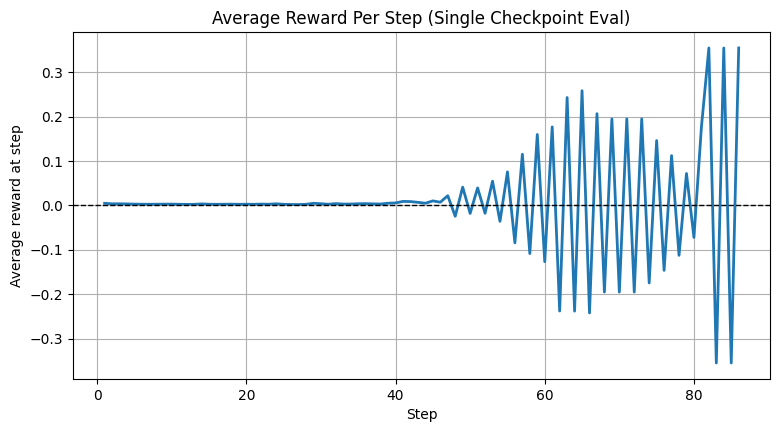

Plotted 86 steps. Last-step sample count: 1


In [5]:
# --------------------------
# Single-checkpoint test
# --------------------------
dataset_path = "tet_dataset_grid125_sigma1e-02_N2000_test.mat"
ckpt_path = "out/03-22-16-26/model_round179.pt"

num_test = 10
seed = 0

score_mode = "softmin"   # "softmin" or "worstk"
softmin_tau = 0.05
worstk_k = 10

patience_eval = 20
max_steps = 150
greedy = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Read tet quality metric from train config (fallback mean_ratio)
tet_quality_mode = resolve_quality_mode_from_ckpt(ckpt_path, default_mode="mean_ratio")

# Load dataset
ds = TetMat73Dataset(dataset_path, load_all=False)
print("dataset size:", ds.num_samples)
T_good = ds.T_good

rng = np.random.default_rng(seed)
test_ids = rng.integers(0, ds.num_samples, size=num_test)

# Evaluate one model
result = evaluate_checkpoint(
    ckpt_path,
    ds,
    test_ids,
    T_good,
    device,
    tet_quality_mode=tet_quality_mode,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    greedy=greedy,
)

print()
print("bad_mean  final_mean best_mean  good_mean  improve_best  gap_to_good  steps_mean")
print(
    f"{result['bad_mean']:+.6f}  "
    f"{result['final_mean']:+.6f}  "
    f"{result['best_mean']:+.6f}  "
    f"{result['good_mean']:+.6f}  "
    f"{result['improve_best']:+.6f}  "
    f"{result['gap_to_good']:+.6f}  "
    f"{result['steps_mean']:.2f}"
)

# Plot average reward at each step index across test samples
step_reward_mean = result["step_reward_mean"]
step_reward_count = result["step_reward_count"]

if step_reward_mean.size == 0:
    print("No step rewards to plot (agent took 0 actions on all test samples).")
else:
    x = np.arange(1, step_reward_mean.size + 1)
    plt.figure(figsize=(9, 4.5))
    plt.plot(x, step_reward_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True)
    plt.xlabel("Step")
    plt.ylabel("Average reward at step")
    plt.title("Average Reward Per Step (Single Checkpoint Eval)")
    plt.show()

    print(f"Plotted {step_reward_mean.size} steps. Last-step sample count: {int(step_reward_count[-1])}")

ds.close()


device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
episode_id: 1
trace_fallback_final_to_best: False
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio

Episode summary
steps=76  best_step=55  final_score=+0.737390  best_seen_score=+0.737390  best_score(T_good)=+0.734448
tet_count: bad=440  final=410  good=384

Action trace (one line per step):
step | op_type      | local_idx | env_action | model_action | valid | delta_score
   0 | edge (3-2)   |       403 |       1385 |          403 | True  | +0.003977
   1 | edge (3-2)   |       255 |       1235 |          255 | True  | +0.004611
   2 | edge (3-2)   |        55 |       1033 |           55 | True  | +0.002594
   3 | edge (3-2)   |       413 |       1389 |          413 | True  | +0.002910
   4 | edge (3-2)   |       407 |       1381 |          407 | True  | +0.004809
   5 | edge (3-2)   |       129 |       1101 |          129 | True  | +0.001997
  

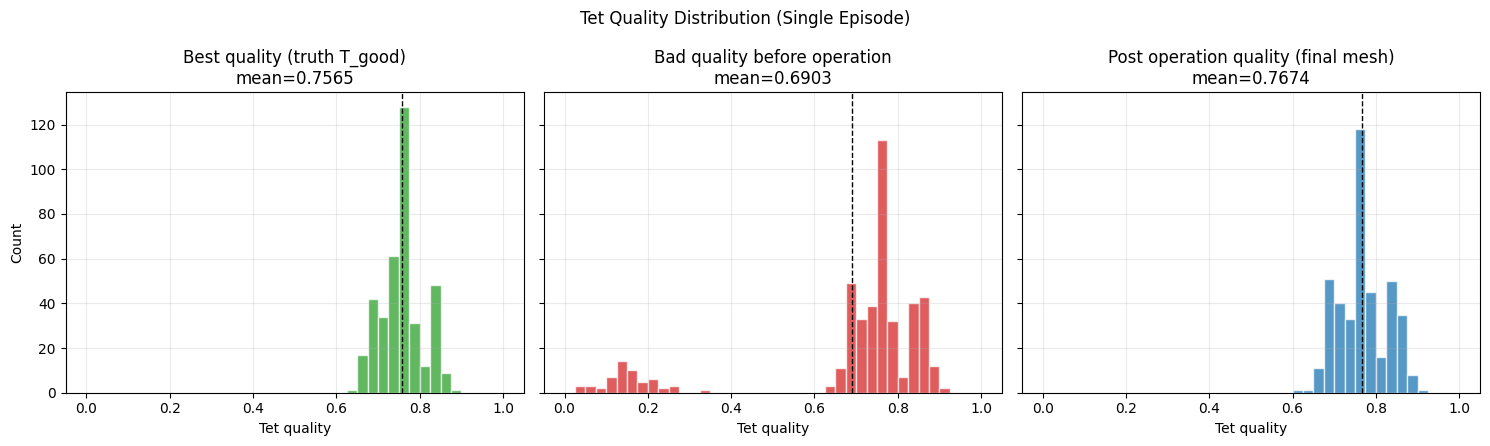

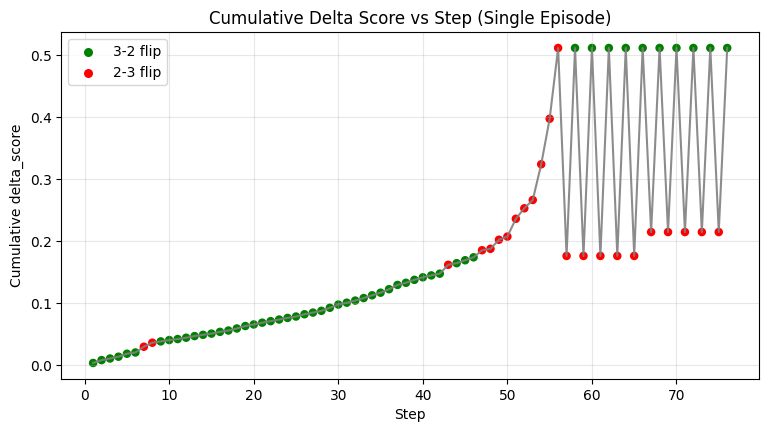

In [7]:
# -----------------------------------------
# Single-episode trace + quality histograms
# -----------------------------------------
dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000_test.mat")
ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")

episode_id = 1
trace_fallback_final_to_best = bool(locals().get("trace_fallback_final_to_best", False))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)
print("episode_id:", episode_id)
print("trace_fallback_final_to_best:", trace_fallback_final_to_best)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Read tet quality metric from train config (fallback mean_ratio)
tet_quality_mode = resolve_quality_mode_from_ckpt(ckpt_path, default_mode="mean_ratio")

ds = TetMat73Dataset(dataset_path, load_all=False)
if not (0 <= int(episode_id) < ds.num_samples):
    raise ValueError(f"episode_id must be in [0, {ds.num_samples-1}]")

P, Tbad = ds.get(int(episode_id))

topo0 = TetMeshTopology(P, Tbad, tet_quality_mode=tet_quality_mode)
model = build_model_from_ckpt(
    ckpt_path,
    device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=max_steps,
        patience_eval=patience_eval,
    ),
)

trace = run_agent_trace_episode(
    P,
    Tbad,
    model,
    device,
    T_good=ds.T_good,
    tet_quality_mode=tet_quality_mode,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    greedy=greedy,
    fallback_final_to_best=trace_fallback_final_to_best,
)

print()
print("Episode summary")
print(
    f"steps={trace['steps']}  best_step={trace['best_step']}  "
    f"final_score={trace['final_score']:+.6f}  "
    f"best_seen_score={trace['best_seen_score']:+.6f}  "
    f"best_score(T_good)={trace['best_score']:+.6f}"
)
print(
    f"tet_count: bad={int(Tbad.shape[0])}  "
    f"final={int(trace['final_tets'].shape[0])}  "
    f"good={int(ds.T_good.shape[0])}"
)

print()
print("Action trace (one line per step):")
print("step | op_type      | local_idx | env_action | model_action | valid | delta_score")
for a in trace["action_log"]:
    print(
        f"{a['step']:4d} | {a['op_type']:<12} | {a['op_local_index']:9d} | "
        f"{a['env_action']:10d} | {a['model_action']:12d} | {str(a['valid']):5s} | {a['delta']:+.6f}"
    )

# Histograms: best-truth / bad-before / post-operation-final
best_q = trace["best_q"]
bad_q = trace["bad_q"]
final_q = trace["final_q"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality (truth T_good)", best_q, "tab:green"),
    ("Bad quality before operation", bad_q, "tab:red"),
    ("Post operation quality (final mesh)", final_q, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Single Episode)")
plt.tight_layout()
plt.show()

# Cumulative delta_score vs step (green: 3-2, red: 2-3)
action_log = trace["action_log"]
if len(action_log) == 0:
    print("No actions taken; skip cumulative delta_score plot.")
else:
    steps = np.arange(1, len(action_log) + 1)
    deltas = np.array([float(a["delta"]) for a in action_log], dtype=np.float64)
    cum_delta = np.cumsum(deltas)

    colors = ["green" if "3-2" in a["op_type"] else "red" for a in action_log]

    plt.figure(figsize=(9, 4.5))
    plt.plot(steps, cum_delta, color="gray", linewidth=1.5, alpha=0.9)
    plt.scatter(steps, cum_delta, c=colors, s=26)

    plt.scatter([], [], c="green", s=30, label="3-2 flip")
    plt.scatter([], [], c="red", s=30, label="2-3 flip")

    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Cumulative delta_score")
    plt.title("Cumulative Delta Score vs Step (Single Episode)")
    plt.legend()
    plt.show()

ds.close()


device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
num_eval_episodes: 200
trace_fallback_final_to_best: False
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio


Aggregate eval:   0%|          | 0/200 [00:00<?, ?it/s]


Aggregate quality stats
episodes=200
bad_mean=0.694036  final_mean=0.767445  best_seen_mean=0.767995  best_mean(T_good)=0.756413


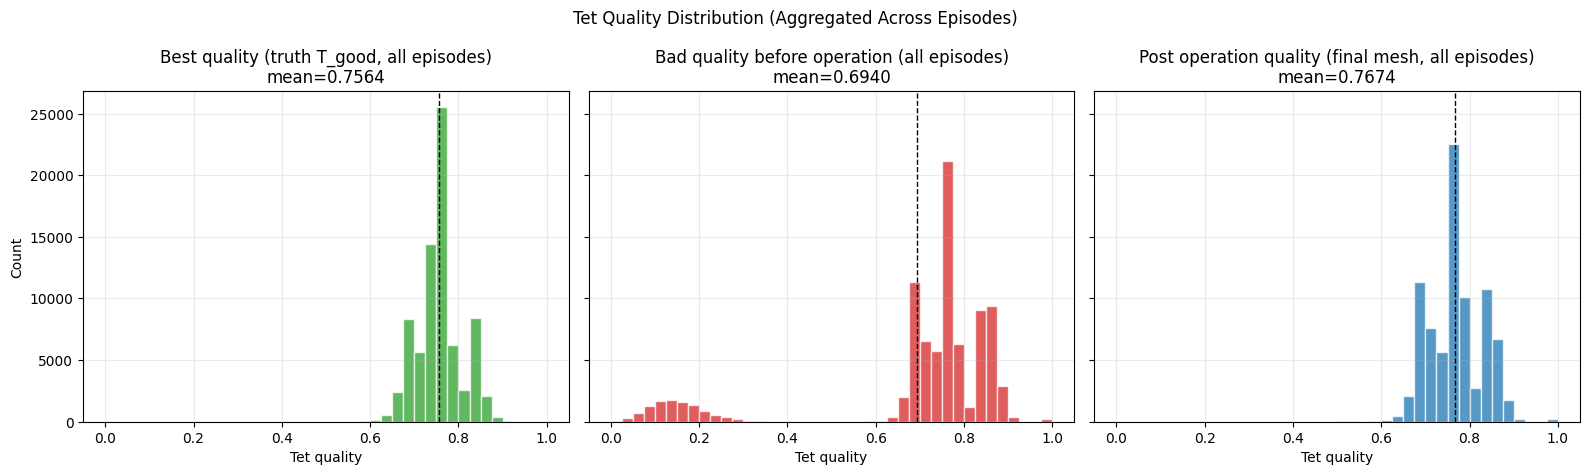

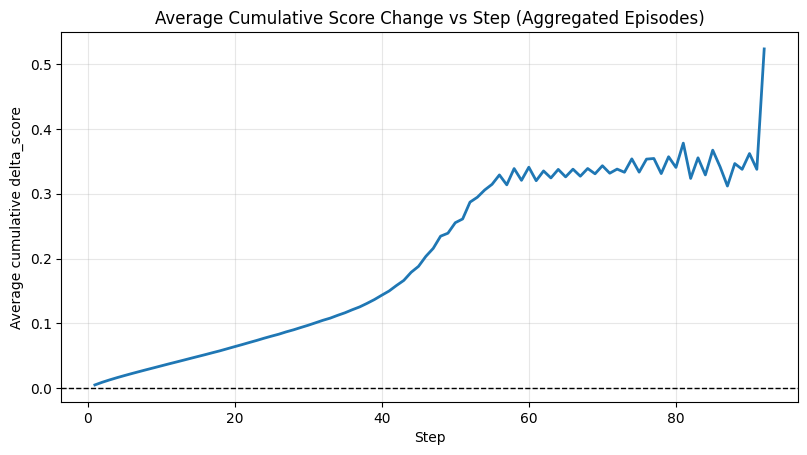

Cumulative curve length: 92 steps
Last-step contributor count: 1


In [8]:
# -------------------------------------------------
# Multi-episode aggregate histograms + avg cum score
# -------------------------------------------------
dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000_test.mat")
ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")

num_eval_episodes = 200
seed_multi = 123
episode_ids = None
trace_fallback_final_to_best = bool(locals().get("trace_fallback_final_to_best", False))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)
print("num_eval_episodes:", num_eval_episodes)
print("trace_fallback_final_to_best:", trace_fallback_final_to_best)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Read tet quality metric from train config (fallback mean_ratio)
tet_quality_mode = resolve_quality_mode_from_ckpt(ckpt_path, default_mode="mean_ratio")

ds = TetMat73Dataset(dataset_path, load_all=False)

if episode_ids is None:
    rng = np.random.default_rng(seed_multi)
    replace = num_eval_episodes > ds.num_samples
    episode_ids = rng.choice(ds.num_samples, size=num_eval_episodes, replace=replace)
else:
    episode_ids = np.asarray(episode_ids, dtype=np.int64)

first_id = int(episode_ids[0])
P0, Tbad0 = ds.get(first_id)
topo0 = TetMeshTopology(P0, Tbad0, tet_quality_mode=tet_quality_mode)
model = build_model_from_ckpt(
    ckpt_path,
    device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=max_steps,
        patience_eval=patience_eval,
    ),
)

all_bad_q = []
all_best_q = []            # truth T_good quality
all_best_seen_q = []       # episode-best during search
all_final_q = []           # final mesh (with/without fallback)
cum_trajs = []

for eid in tqdm(episode_ids, desc="Aggregate eval", leave=False):
    P, Tbad = ds.get(int(eid))
    tr = run_agent_trace_episode(
        P,
        Tbad,
        model,
        device,
        T_good=ds.T_good,
        tet_quality_mode=tet_quality_mode,
        score_mode=score_mode,
        softmin_tau=softmin_tau,
        worstk_k=worstk_k,
        patience_eval=patience_eval,
        max_steps=max_steps,
        greedy=greedy,
        fallback_final_to_best=trace_fallback_final_to_best,
    )

    all_bad_q.append(tr["bad_q"])
    all_best_q.append(tr["best_q"])
    all_best_seen_q.append(tr["best_seen_q"])
    all_final_q.append(tr["final_q"])

    deltas = np.array([float(a["delta"]) for a in tr["action_log"]], dtype=np.float64)
    cum = np.cumsum(deltas) if deltas.size > 0 else np.zeros((0,), dtype=np.float64)
    cum_trajs.append(cum)

bad_q_all = np.concatenate(all_bad_q) if len(all_bad_q) > 0 else np.zeros((0,), dtype=np.float64)
best_q_all = np.concatenate(all_best_q) if len(all_best_q) > 0 else np.zeros((0,), dtype=np.float64)
best_seen_q_all = np.concatenate(all_best_seen_q) if len(all_best_seen_q) > 0 else np.zeros((0,), dtype=np.float64)
final_q_all = np.concatenate(all_final_q) if len(all_final_q) > 0 else np.zeros((0,), dtype=np.float64)

print()
print("Aggregate quality stats")
print(f"episodes={len(episode_ids)}")
print(
    f"bad_mean={bad_q_all.mean():.6f}  "
    f"final_mean={final_q_all.mean():.6f}  "
    f"best_seen_mean={best_seen_q_all.mean():.6f}  "
    f"best_mean(T_good)={best_q_all.mean():.6f}"
)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality (truth T_good, all episodes)", best_q_all, "tab:green"),
    ("Bad quality before operation (all episodes)", bad_q_all, "tab:red"),
    ("Post operation quality (final mesh, all episodes)", final_q_all, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Aggregated Across Episodes)")
plt.tight_layout()
plt.show()

max_len = max((len(c) for c in cum_trajs), default=0)
if max_len == 0:
    print("No actions taken in all selected episodes; skip cumulative plot.")
else:
    cum_mean = np.full(max_len, np.nan, dtype=np.float64)
    cum_count = np.zeros(max_len, dtype=np.int64)
    for t in range(max_len):
        vals = [c[t] for c in cum_trajs if t < len(c)]
        if vals:
            cum_mean[t] = float(np.mean(vals))
            cum_count[t] = int(len(vals))

    x = np.arange(1, max_len + 1)
    plt.figure(figsize=(9.5, 4.8))
    plt.plot(x, cum_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Average cumulative delta_score")
    plt.title("Average Cumulative Score Change vs Step (Aggregated Episodes)")
    plt.show()

    print(f"Cumulative curve length: {max_len} steps")
    print(f"Last-step contributor count: {int(cum_count[-1])}")

ds.close()


In [9]:
# -------------------------------------------------
# Min tet-quality summary across evaluated episodes
# -------------------------------------------------
if "all_bad_q" not in locals() or "all_final_q" not in locals() or "all_best_q" not in locals():
    raise RuntimeError("Run the multi-episode evaluation cell first (it defines all_bad_q, all_final_q, all_best_q).")

if len(all_bad_q) == 0 or len(all_final_q) == 0 or len(all_best_q) == 0:
    print("No episode traces available.")
else:
    min_bad_per_ep = np.array([float(np.min(q)) for q in all_bad_q], dtype=np.float64)
    min_final_per_ep = np.array([float(np.min(q)) for q in all_final_q], dtype=np.float64)
    min_best_per_ep = np.array([float(np.min(q)) for q in all_best_q], dtype=np.float64)

    print("Average min tet quality before RL :", f"{min_bad_per_ep.mean():.6f}")
    print("Average min tet quality after RL  :", f"{min_final_per_ep.mean():.6f}")
    print("Average min tet quality of T_good :", f"{min_best_per_ep.mean():.6f}")
    print("Average improvement in min quality:", f"{(min_final_per_ep - min_bad_per_ep).mean():+.6f}")
    print("Gap to T_good                     :", f"{(min_final_per_ep - min_best_per_ep).mean():+.6f}")

    if "all_best_seen_q" in locals() and len(all_best_seen_q) == len(all_final_q):
        min_best_seen_per_ep = np.array([float(np.min(q)) for q in all_best_seen_q], dtype=np.float64)
        print("Average min tet quality best-seen:", f"{min_best_seen_per_ep.mean():.6f}")
        print("Final - best-seen gap            :", f"{(min_final_per_ep - min_best_seen_per_ep).mean():+.6f}")


Average min tet quality before RL : 0.037963
Average min tet quality after RL  : 0.537180
Average min tet quality of T_good : 0.616823
Average improvement in min quality: +0.499217
Gap to T_good                     : -0.079643
Average min tet quality best-seen: 0.610172
Final - best-seen gap            : -0.072992


dataset: tet_dataset_grid125_sigma1e-02_N2000_test.mat
checkpoint (for metric lookup): out/03-22-16-26/model_round179.pt
single episode id: 1
aggregate episodes: 200
baseline_fallback_final_to_best: False
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio

Greedy baseline episode summary
steps=83  best_step=62  final_score=+0.737308  best_seen_score=+0.737308
tet_count: bad=440  final=465  good=384

Greedy action trace (one line per step):
step | op_type      | local_idx | env_action | valid | delta_score | worst_tid
   0 | face (2-3)   |       574 |        574 | True  | +0.005859 |       236
   1 | face (2-3)   |       406 |        406 | True  | +0.005006 |       157
   2 | edge (3-2)   |       403 |       1389 | True  | +0.004999 |       210
   3 | edge (3-2)   |       409 |       1393 | True  | +0.004936 |       213
   4 | face (2-3)   |       158 |        158 | True  | +0.005307 |        57
   5 | fac

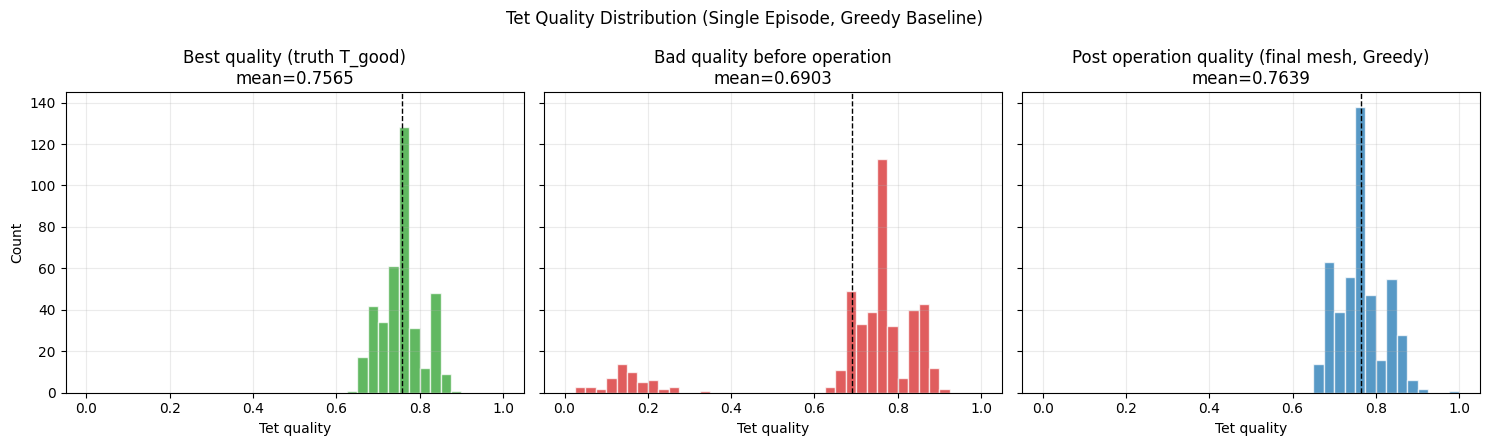

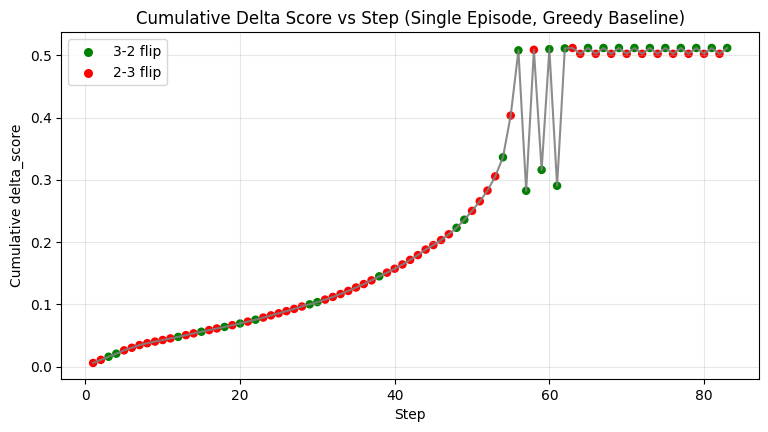

Greedy aggregate eval:   0%|          | 0/200 [00:00<?, ?it/s]


Greedy aggregate quality stats
episodes=200
bad_mean=0.694036  final_mean=0.766893  best_seen_mean=0.766910  best_mean(T_good)=0.756413


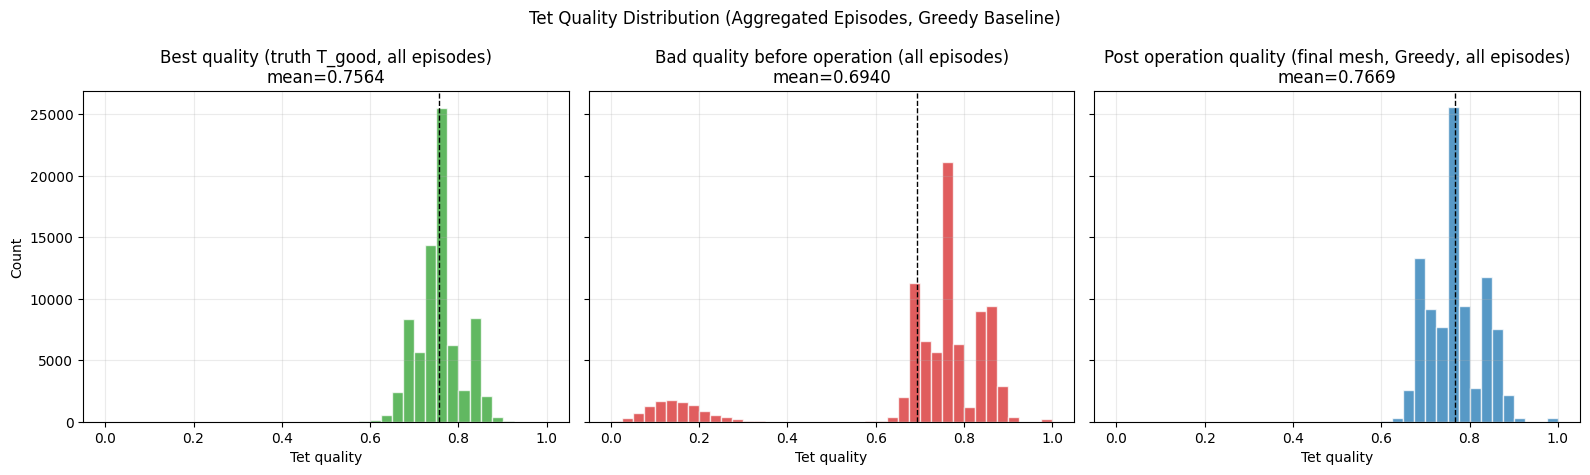

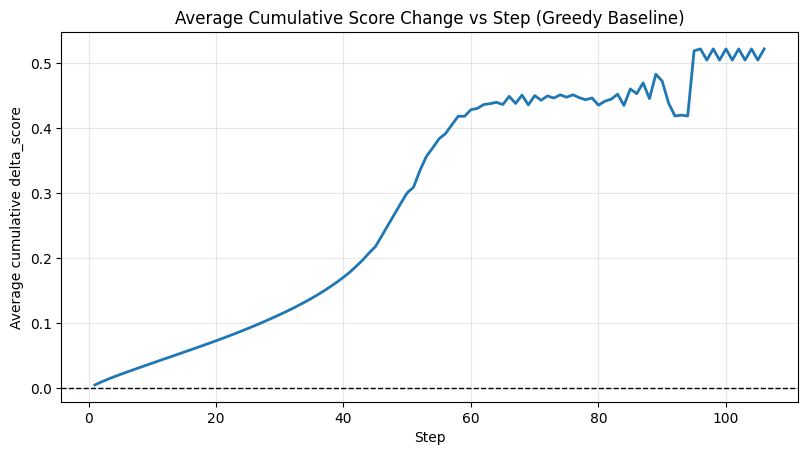

Cumulative curve length: 106 steps
Last-step contributor count: 1


In [10]:
# -----------------------------------------------------------------
# Greedy baseline (worst-tet local search) for side-by-side comparison
# -----------------------------------------------------------------
from greedy_refine_baseline import run_greedy_trace_episode

baseline_dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000_test.mat")
baseline_ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")
baseline_episode_id = int(locals().get("episode_id", 12))
baseline_num_eval_episodes = int(locals().get("num_eval_episodes", 200))
baseline_seed = int(locals().get("seed_multi", 123))
baseline_episode_ids = locals().get("episode_ids", None)
baseline_fallback_final_to_best = bool(locals().get("trace_fallback_final_to_best", False))

print("dataset:", baseline_dataset_path)
print("checkpoint (for metric lookup):", baseline_ckpt_path)
print("single episode id:", baseline_episode_id)
print("aggregate episodes:", baseline_num_eval_episodes)
print("baseline_fallback_final_to_best:", baseline_fallback_final_to_best)

if not os.path.exists(baseline_ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {baseline_ckpt_path}")

baseline_tet_quality_mode = resolve_quality_mode_from_ckpt(baseline_ckpt_path, default_mode="mean_ratio")

# -----------------------------
# Single-episode greedy baseline
# -----------------------------
ds = TetMat73Dataset(baseline_dataset_path, load_all=False)
if not (0 <= baseline_episode_id < ds.num_samples):
    raise ValueError(f"baseline_episode_id must be in [0, {ds.num_samples-1}]")

P, Tbad = ds.get(baseline_episode_id)
greedy_trace = run_greedy_trace_episode(
    P,
    Tbad,
    tet_quality_mode=baseline_tet_quality_mode,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    fallback_final_to_best=baseline_fallback_final_to_best,
)

good_q_g = TetMeshTopology(P, ds.T_good, tet_quality_mode=baseline_tet_quality_mode).tet_quality.copy()

print()
print("Greedy baseline episode summary")
print(
    f"steps={greedy_trace['steps']}  "
    f"best_step={greedy_trace['best_step']}  "
    f"final_score={greedy_trace['final_score']:+.6f}  "
    f"best_seen_score={greedy_trace['best_score']:+.6f}"
)
print(
    f"tet_count: bad={int(Tbad.shape[0])}  "
    f"final={int(greedy_trace['final_tets'].shape[0])}  "
    f"good={int(ds.T_good.shape[0])}"
)

print()
print("Greedy action trace (one line per step):")
print("step | op_type      | local_idx | env_action | valid | delta_score | worst_tid")
for a in greedy_trace["action_log"]:
    print(
        f"{a['step']:4d} | {a['op_type']:<12} | {a['op_local_index']:9d} | "
        f"{a['env_action']:10d} | {str(a['valid']):5s} | {a['delta']:+.6f} | {a['worst_tid']:9d}"
    )

best_q_g = good_q_g
bad_q_g = greedy_trace["bad_q"]
final_q_g = greedy_trace["final_q"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality (truth T_good)", best_q_g, "tab:green"),
    ("Bad quality before operation", bad_q_g, "tab:red"),
    ("Post operation quality (final mesh, Greedy)", final_q_g, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Single Episode, Greedy Baseline)")
plt.tight_layout()
plt.show()

action_log_g = greedy_trace["action_log"]
if len(action_log_g) == 0:
    print("No actions taken by greedy baseline; skip cumulative delta_score plot.")
else:
    steps_g = np.arange(1, len(action_log_g) + 1)
    deltas_g = np.array([float(a["delta"]) for a in action_log_g], dtype=np.float64)
    cum_delta_g = np.cumsum(deltas_g)
    colors_g = ["green" if "3-2" in a["op_type"] else "red" for a in action_log_g]

    plt.figure(figsize=(9, 4.5))
    plt.plot(steps_g, cum_delta_g, color="gray", linewidth=1.5, alpha=0.9)
    plt.scatter(steps_g, cum_delta_g, c=colors_g, s=26)
    plt.scatter([], [], c="green", s=30, label="3-2 flip")
    plt.scatter([], [], c="red", s=30, label="2-3 flip")
    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Cumulative delta_score")
    plt.title("Cumulative Delta Score vs Step (Single Episode, Greedy Baseline)")
    plt.legend()
    plt.show()

# ----------------------------------
# Multi-episode greedy aggregate view
# ----------------------------------
if baseline_episode_ids is None:
    rng = np.random.default_rng(baseline_seed)
    replace = baseline_num_eval_episodes > ds.num_samples
    baseline_episode_ids = rng.choice(ds.num_samples, size=baseline_num_eval_episodes, replace=replace)
else:
    baseline_episode_ids = np.asarray(baseline_episode_ids, dtype=np.int64)

baseline_all_bad_q = []
baseline_all_best_q = []       # truth T_good
baseline_all_best_seen_q = []  # episode-best during search
baseline_all_final_q = []
baseline_cum_trajs = []

for eid in tqdm(baseline_episode_ids, desc="Greedy aggregate eval", leave=False):
    P, Tbad = ds.get(int(eid))
    tr = run_greedy_trace_episode(
        P,
        Tbad,
        tet_quality_mode=baseline_tet_quality_mode,
        score_mode=score_mode,
        softmin_tau=softmin_tau,
        worstk_k=worstk_k,
        patience_eval=patience_eval,
        max_steps=max_steps,
        fallback_final_to_best=baseline_fallback_final_to_best,
    )
    q_good = TetMeshTopology(P, ds.T_good, tet_quality_mode=baseline_tet_quality_mode).tet_quality.copy()

    baseline_all_bad_q.append(tr["bad_q"])
    baseline_all_best_q.append(q_good)
    baseline_all_best_seen_q.append(tr["best_q"])
    baseline_all_final_q.append(tr["final_q"])

    deltas = np.array([float(a["delta"]) for a in tr["action_log"]], dtype=np.float64)
    baseline_cum_trajs.append(np.cumsum(deltas) if deltas.size > 0 else np.zeros((0,), dtype=np.float64))

baseline_bad_q_all = np.concatenate(baseline_all_bad_q) if len(baseline_all_bad_q) > 0 else np.zeros((0,), dtype=np.float64)
baseline_best_q_all = np.concatenate(baseline_all_best_q) if len(baseline_all_best_q) > 0 else np.zeros((0,), dtype=np.float64)
baseline_best_seen_q_all = np.concatenate(baseline_all_best_seen_q) if len(baseline_all_best_seen_q) > 0 else np.zeros((0,), dtype=np.float64)
baseline_final_q_all = np.concatenate(baseline_all_final_q) if len(baseline_all_final_q) > 0 else np.zeros((0,), dtype=np.float64)

print()
print("Greedy aggregate quality stats")
print(f"episodes={len(baseline_episode_ids)}")
print(
    f"bad_mean={baseline_bad_q_all.mean():.6f}  "
    f"final_mean={baseline_final_q_all.mean():.6f}  "
    f"best_seen_mean={baseline_best_seen_q_all.mean():.6f}  "
    f"best_mean(T_good)={baseline_best_q_all.mean():.6f}"
)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality (truth T_good, all episodes)", baseline_best_q_all, "tab:green"),
    ("Bad quality before operation (all episodes)", baseline_bad_q_all, "tab:red"),
    ("Post operation quality (final mesh, Greedy, all episodes)", baseline_final_q_all, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Aggregated Episodes, Greedy Baseline)")
plt.tight_layout()
plt.show()

baseline_max_len = max((len(c) for c in baseline_cum_trajs), default=0)
if baseline_max_len == 0:
    print("No actions taken in all selected episodes; skip cumulative plot.")
else:
    baseline_cum_mean = np.full(baseline_max_len, np.nan, dtype=np.float64)
    baseline_cum_count = np.zeros(baseline_max_len, dtype=np.int64)
    for t in range(baseline_max_len):
        vals = [c[t] for c in baseline_cum_trajs if t < len(c)]
        if vals:
            baseline_cum_mean[t] = float(np.mean(vals))
            baseline_cum_count[t] = int(len(vals))

    x = np.arange(1, baseline_max_len + 1)
    plt.figure(figsize=(9.5, 4.8))
    plt.plot(x, baseline_cum_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Average cumulative delta_score")
    plt.title("Average Cumulative Score Change vs Step (Greedy Baseline)")
    plt.show()

    print(f"Cumulative curve length: {baseline_max_len} steps")
    print(f"Last-step contributor count: {int(baseline_cum_count[-1])}")

ds.close()


dataset: tet_dataset_grid125_sigma1e-02_N2000_test.mat
checkpoint: out/03-22-16-26/model_round179.pt
single episode id: 1
num_eval_episodes: 200
device: cpu
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio

Single-episode tet-count summary
ideal_tets=384  RL: steps=76, final_tets=410  Greedy: steps=83, final_tets=465


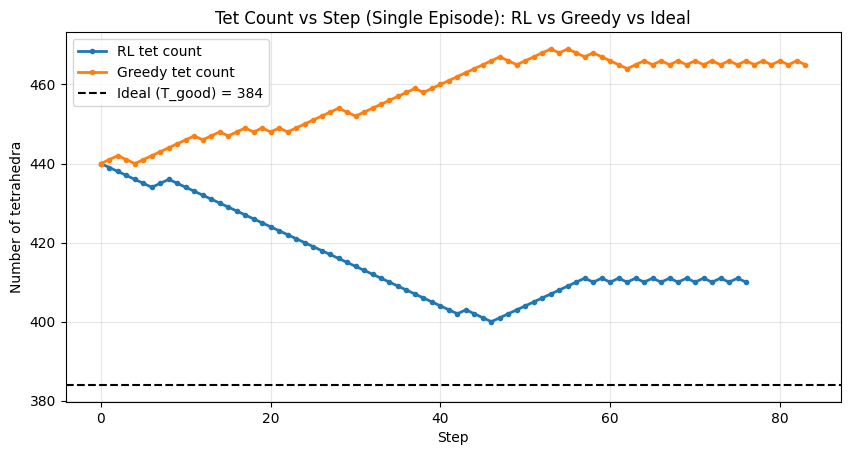

Tet-count aggregate eval:   0%|          | 0/200 [00:00<?, ?it/s]


Aggregate tet-count summary
episodes=200
ideal_tets_mean=384.00  RL_final_tets_mean=413.24  Greedy_final_tets_mean=464.86


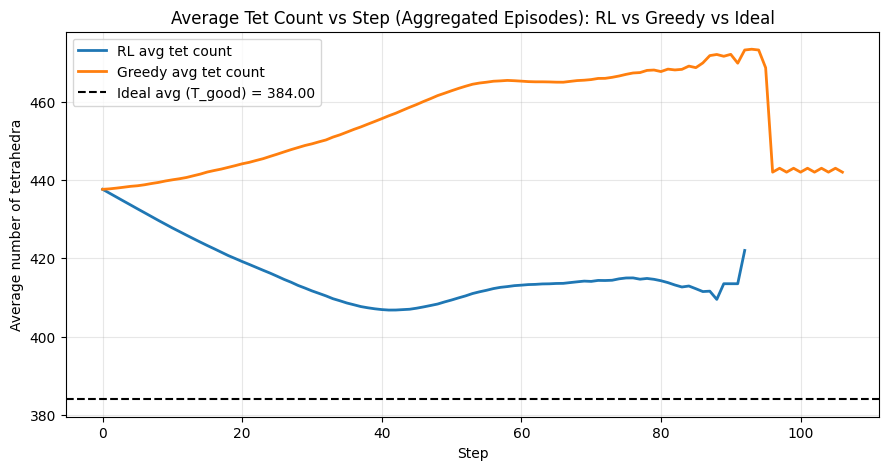

RL curve length=93 steps, last-step contributors=1
Greedy curve length=107 steps, last-step contributors=1


In [11]:
# -----------------------------------------------------------------
# Tet-count trajectory comparison: RL vs Greedy vs Ideal (T_good)
# -----------------------------------------------------------------
import importlib
import greedy_refine_baseline as grb
importlib.reload(grb)
run_greedy_trace_episode = grb.run_greedy_trace_episode


def replay_tet_count_trajectory(P, T_init, action_log, tet_quality_mode="mean_ratio"):
    topo = TetMeshTopology(P, T_init.copy(), tet_quality_mode=tet_quality_mode)
    counts = [int(topo.tets.shape[0])]  # step 0 (before any action)
    for a in action_log:
        _ = topo.apply_action(int(a["env_action"]))
        counts.append(int(topo.tets.shape[0]))
    return np.asarray(counts, dtype=np.int64)


def stepwise_mean(trajs):
    max_len = max((len(t) for t in trajs), default=0)
    if max_len == 0:
        return np.zeros((0,), dtype=np.float64), np.zeros((0,), dtype=np.int64)
    arr = np.full((len(trajs), max_len), np.nan, dtype=np.float64)
    for i, t in enumerate(trajs):
        arr[i, :len(t)] = t
    mean = np.nanmean(arr, axis=0)
    count = np.sum(~np.isnan(arr), axis=0).astype(np.int64)
    return mean, count


# Inputs (reuse prior notebook settings if available)
tet_count_dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000_test.mat")
tet_count_ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")
tet_count_episode_id = int(locals().get("episode_id", 12))
tet_count_num_eval_episodes = int(locals().get("num_eval_episodes", 200))
tet_count_seed = int(locals().get("seed_multi", 123))
tet_count_episode_ids = locals().get("episode_ids", None)

tet_count_score_mode = locals().get("score_mode", "softmin")
tet_count_softmin_tau = float(locals().get("softmin_tau", 0.05))
tet_count_worstk_k = int(locals().get("worstk_k", 10))
tet_count_patience_eval = int(locals().get("patience_eval", 20))
tet_count_max_steps = int(locals().get("max_steps", 150))
tet_count_greedy_policy = bool(locals().get("greedy", True))

tet_count_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("dataset:", tet_count_dataset_path)
print("checkpoint:", tet_count_ckpt_path)
print("single episode id:", tet_count_episode_id)
print("num_eval_episodes:", tet_count_num_eval_episodes)
print("device:", tet_count_device)

if not os.path.exists(tet_count_ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {tet_count_ckpt_path}")

# Use train-time tet quality metric when available
tet_count_quality_mode = resolve_quality_mode_from_ckpt(tet_count_ckpt_path, default_mode="mean_ratio")

ds = TetMat73Dataset(tet_count_dataset_path, load_all=False)
if not (0 <= tet_count_episode_id < ds.num_samples):
    raise ValueError(f"tet_count_episode_id must be in [0, {ds.num_samples-1}]")

# Build RL model once
P0, Tbad0 = ds.get(int(tet_count_episode_id))
topo0 = TetMeshTopology(P0, Tbad0, tet_quality_mode=tet_count_quality_mode)
model = build_model_from_ckpt(
    tet_count_ckpt_path,
    tet_count_device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=tet_count_max_steps,
        patience_eval=tet_count_patience_eval,
    ),
)

# ----------------------
# Single-episode compare
# ----------------------
P, Tbad = ds.get(int(tet_count_episode_id))
ideal_topo = TetMeshTopology(P, ds.T_good, tet_quality_mode=tet_count_quality_mode)
ideal_tet_count = int(ideal_topo.tets.shape[0])

rl_trace_count = run_agent_trace_episode(
    P,
    Tbad,
    model,
    tet_count_device,
    tet_quality_mode=tet_count_quality_mode,
    score_mode=tet_count_score_mode,
    softmin_tau=tet_count_softmin_tau,
    worstk_k=tet_count_worstk_k,
    patience_eval=tet_count_patience_eval,
    max_steps=tet_count_max_steps,
    greedy=tet_count_greedy_policy,
    fallback_final_to_best=True,
)

gr_trace_count = run_greedy_trace_episode(
    P,
    Tbad,
    tet_quality_mode=tet_count_quality_mode,
    score_mode=tet_count_score_mode,
    softmin_tau=tet_count_softmin_tau,
    worstk_k=tet_count_worstk_k,
    patience_eval=tet_count_patience_eval,
    max_steps=tet_count_max_steps,
    fallback_final_to_best=True,
)

rl_tet_counts = replay_tet_count_trajectory(P, Tbad, rl_trace_count["action_log"], tet_count_quality_mode)
gr_tet_counts = replay_tet_count_trajectory(P, Tbad, gr_trace_count["action_log"], tet_count_quality_mode)

print()
print("Single-episode tet-count summary")
print(
    f"ideal_tets={ideal_tet_count}  "
    f"RL: steps={len(rl_tet_counts)-1}, final_tets={int(rl_tet_counts[-1])}  "
    f"Greedy: steps={len(gr_tet_counts)-1}, final_tets={int(gr_tet_counts[-1])}"
)

x_rl = np.arange(len(rl_tet_counts))
x_gr = np.arange(len(gr_tet_counts))

plt.figure(figsize=(10, 4.8))
plt.plot(x_rl, rl_tet_counts, "-o", markersize=3, linewidth=2, label="RL tet count")
plt.plot(x_gr, gr_tet_counts, "-o", markersize=3, linewidth=2, label="Greedy tet count")
plt.axhline(ideal_tet_count, color="k", linestyle="--", linewidth=1.5, label=f"Ideal (T_good) = {ideal_tet_count}")
plt.grid(True, alpha=0.3)
plt.xlabel("Step")
plt.ylabel("Number of tetrahedra")
plt.title("Tet Count vs Step (Single Episode): RL vs Greedy vs Ideal")
plt.legend()
plt.show()

# ------------------------
# Multi-episode comparison
# ------------------------
if tet_count_episode_ids is None:
    rng = np.random.default_rng(tet_count_seed)
    replace = tet_count_num_eval_episodes > ds.num_samples
    tet_count_episode_ids = rng.choice(ds.num_samples, size=tet_count_num_eval_episodes, replace=replace)
else:
    tet_count_episode_ids = np.asarray(tet_count_episode_ids, dtype=np.int64)

rl_count_trajs = []
gr_count_trajs = []
ideal_counts = []

for eid in tqdm(tet_count_episode_ids, desc="Tet-count aggregate eval", leave=False):
    P_i, Tbad_i = ds.get(int(eid))

    ideal_topo_i = TetMeshTopology(P_i, ds.T_good, tet_quality_mode=tet_count_quality_mode)
    ideal_counts.append(int(ideal_topo_i.tets.shape[0]))

    rl_trace_i = run_agent_trace_episode(
        P_i,
        Tbad_i,
        model,
        tet_count_device,
        tet_quality_mode=tet_count_quality_mode,
        score_mode=tet_count_score_mode,
        softmin_tau=tet_count_softmin_tau,
        worstk_k=tet_count_worstk_k,
        patience_eval=tet_count_patience_eval,
        max_steps=tet_count_max_steps,
        greedy=tet_count_greedy_policy,
        fallback_final_to_best=True,
    )

    gr_trace_i = run_greedy_trace_episode(
        P_i,
        Tbad_i,
        tet_quality_mode=tet_count_quality_mode,
        score_mode=tet_count_score_mode,
        softmin_tau=tet_count_softmin_tau,
        worstk_k=tet_count_worstk_k,
        patience_eval=tet_count_patience_eval,
        max_steps=tet_count_max_steps,
        fallback_final_to_best=True,
    )

    rl_count_trajs.append(replay_tet_count_trajectory(P_i, Tbad_i, rl_trace_i["action_log"], tet_count_quality_mode))
    gr_count_trajs.append(replay_tet_count_trajectory(P_i, Tbad_i, gr_trace_i["action_log"], tet_count_quality_mode))

rl_count_mean, rl_count_n = stepwise_mean(rl_count_trajs)
gr_count_mean, gr_count_n = stepwise_mean(gr_count_trajs)
ideal_count_mean = float(np.mean(ideal_counts)) if len(ideal_counts) else np.nan

print()
print("Aggregate tet-count summary")
print(f"episodes={len(tet_count_episode_ids)}")
print(
    f"ideal_tets_mean={ideal_count_mean:.2f}  "
    f"RL_final_tets_mean={float(np.mean([t[-1] for t in rl_count_trajs])):.2f}  "
    f"Greedy_final_tets_mean={float(np.mean([t[-1] for t in gr_count_trajs])):.2f}"
)

x_rl_m = np.arange(len(rl_count_mean))
x_gr_m = np.arange(len(gr_count_mean))

plt.figure(figsize=(10.5, 5.0))
if len(rl_count_mean) > 0:
    plt.plot(x_rl_m, rl_count_mean, "-", linewidth=2, label="RL avg tet count")
if len(gr_count_mean) > 0:
    plt.plot(x_gr_m, gr_count_mean, "-", linewidth=2, label="Greedy avg tet count")
if np.isfinite(ideal_count_mean):
    plt.axhline(ideal_count_mean, color="k", linestyle="--", linewidth=1.5, label=f"Ideal avg (T_good) = {ideal_count_mean:.2f}")

plt.grid(True, alpha=0.3)
plt.xlabel("Step")
plt.ylabel("Average number of tetrahedra")
plt.title("Average Tet Count vs Step (Aggregated Episodes): RL vs Greedy vs Ideal")
plt.legend()
plt.show()

if len(rl_count_n) > 0 and len(gr_count_n) > 0:
    print(f"RL curve length={len(rl_count_mean)} steps, last-step contributors={int(rl_count_n[-1])}")
    print(f"Greedy curve length={len(gr_count_mean)} steps, last-step contributors={int(gr_count_n[-1])}")

ds.close()


In [ ]:
# ---------------------------------------------------------
# Min tet-quality summary across episodes (Greedy baseline)
# ---------------------------------------------------------
if (
    "baseline_all_bad_q" not in locals()
    or "baseline_all_final_q" not in locals()
    or "baseline_all_best_q" not in locals()
):
    raise RuntimeError(
        "Run the greedy aggregate evaluation cell first "
        "(it defines baseline_all_bad_q, baseline_all_final_q, baseline_all_best_q)."
    )

if len(baseline_all_bad_q) == 0 or len(baseline_all_final_q) == 0 or len(baseline_all_best_q) == 0:
    print("No greedy episode traces available.")
else:
    min_bad_per_ep = np.array([float(np.min(q)) for q in baseline_all_bad_q], dtype=np.float64)
    min_final_per_ep = np.array([float(np.min(q)) for q in baseline_all_final_q], dtype=np.float64)
    min_best_per_ep = np.array([float(np.min(q)) for q in baseline_all_best_q], dtype=np.float64)

    print("Average min tet quality before Greedy :", f"{min_bad_per_ep.mean():.6f}")
    print("Average min tet quality after Greedy  :", f"{min_final_per_ep.mean():.6f}")
    print("Average min tet quality of T_good     :", f"{min_best_per_ep.mean():.6f}")
    print("Average improvement in min quality    :", f"{(min_final_per_ep - min_bad_per_ep).mean():+.6f}")
    print("Gap to T_good                         :", f"{(min_final_per_ep - min_best_per_ep).mean():+.6f}")

    if "baseline_all_best_seen_q" in locals() and len(baseline_all_best_seen_q) == len(baseline_all_final_q):
        min_best_seen_per_ep = np.array([float(np.min(q)) for q in baseline_all_best_seen_q], dtype=np.float64)
        print("Average min tet quality best-seen     :", f"{min_best_seen_per_ep.mean():.6f}")
        print("Final - best-seen gap                 :", f"{(min_final_per_ep - min_best_seen_per_ep).mean():+.6f}")

